# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Kadek Nathania Gavrila Astika | 5054251050 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [3]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore", category=ConvergenceWarning) 
RANDOM_STATE = 42
MAX_ITER = 300

In [4]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Nama kolom asli punya spasi di depan, dirapikan
df.columns = df.columns.str.strip()

# Jumlah baris dan kolom
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

# Tipe data (sekaligus jumlah non-null per kolom)
df.info()

# Jumlah missing value
print("\nTotal missing value:", df.isnull().sum().sum())

# Statistik deskriptif
df.describe().T

Jumlah baris: 7043
Jumlah kolom: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


       Jumlah  Persentase (%)
Churn                        
No       5174           73.46
Yes      1869           26.54


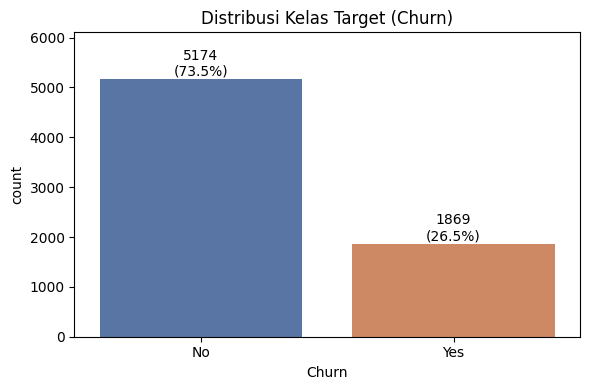

In [5]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(pd.DataFrame({"Jumlah": churn_counts, "Persentase (%)": churn_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Churn", order=["No", "Yes"], hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h)}\n({h / len(df) * 100:.1f}%)", (p.get_x() + p.get_width() / 2, h),
                ha="center", va="bottom", fontsize=10)
ax.set_title("Distribusi Kelas Target (Churn)")
ax.set_ylim(0, churn_counts.max() * 1.18)
plt.tight_layout()
plt.show()

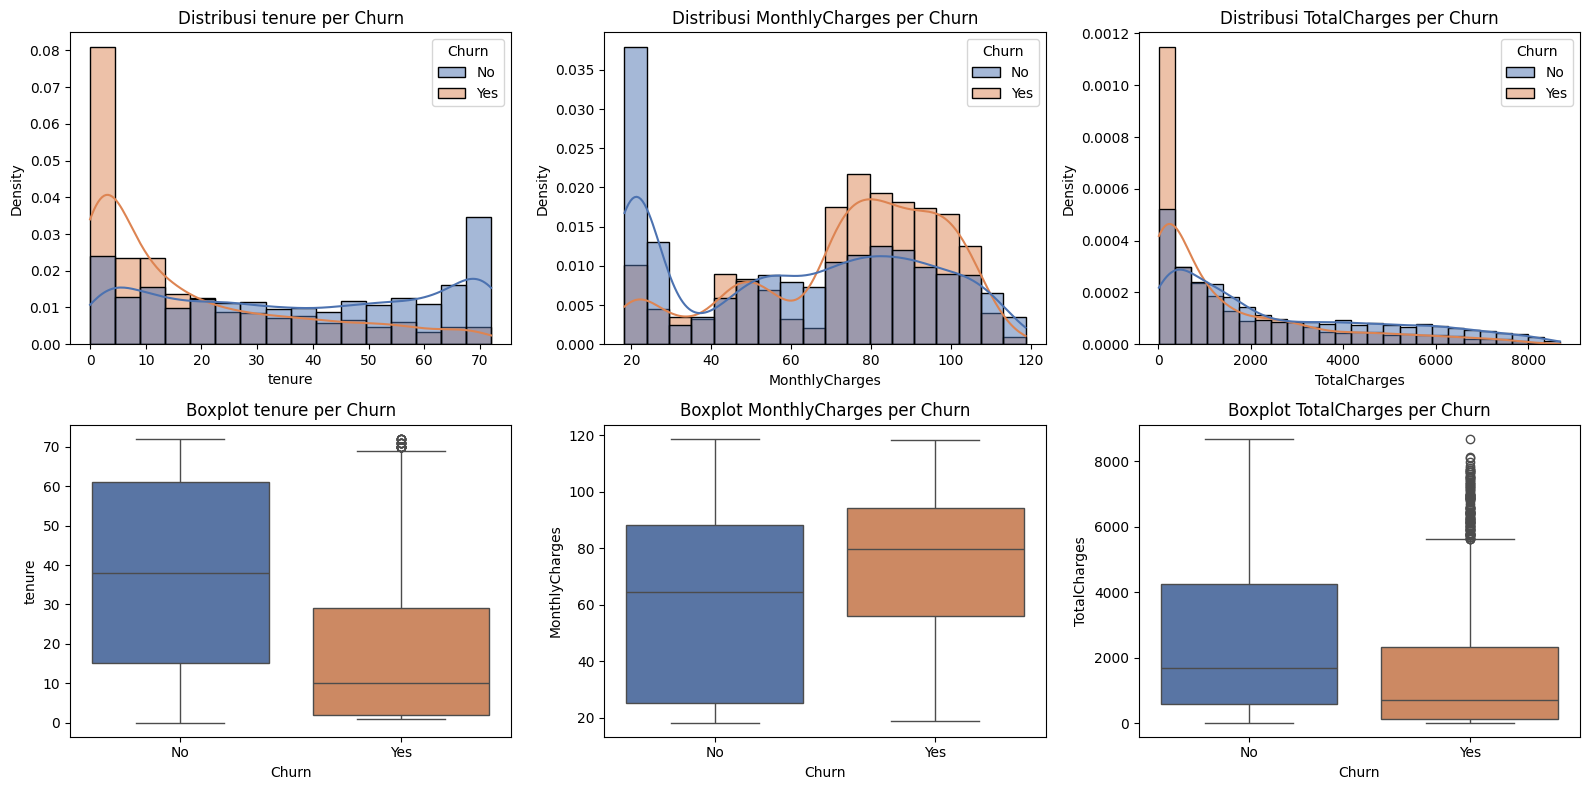

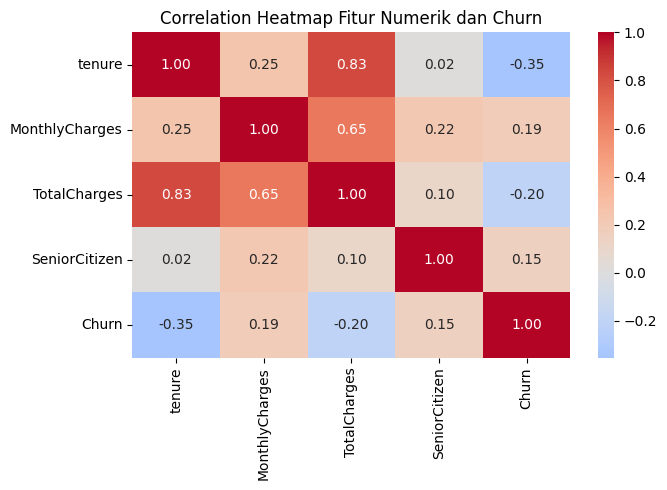

In [6]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
# TotalCharges masih bertipe object; dikonversi sementara untuk keperluan visualisasi
df_eda = df.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(num_cols):
    sns.histplot(data=df_eda, x=col, hue="Churn", kde=True, stat="density",
                 common_norm=False, ax=axes[0, i], palette=["#4C72B0", "#DD8452"])
    axes[0, i].set_title(f"Distribusi {col} per Churn")
    sns.boxplot(data=df_eda, x="Churn", y=col, hue="Churn", ax=axes[1, i],
                palette=["#4C72B0", "#DD8452"], legend=False)
    axes[1, i].set_title(f"Boxplot {col} per Churn")
plt.tight_layout()
plt.show()

# Correlation heatmap fitur numerik + target
corr_df = df_eda[num_cols + ["SeniorCitizen"]].copy()
corr_df["Churn"] = (df_eda["Churn"] == "Yes").astype(int)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap Fitur Numerik dan Churn")
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

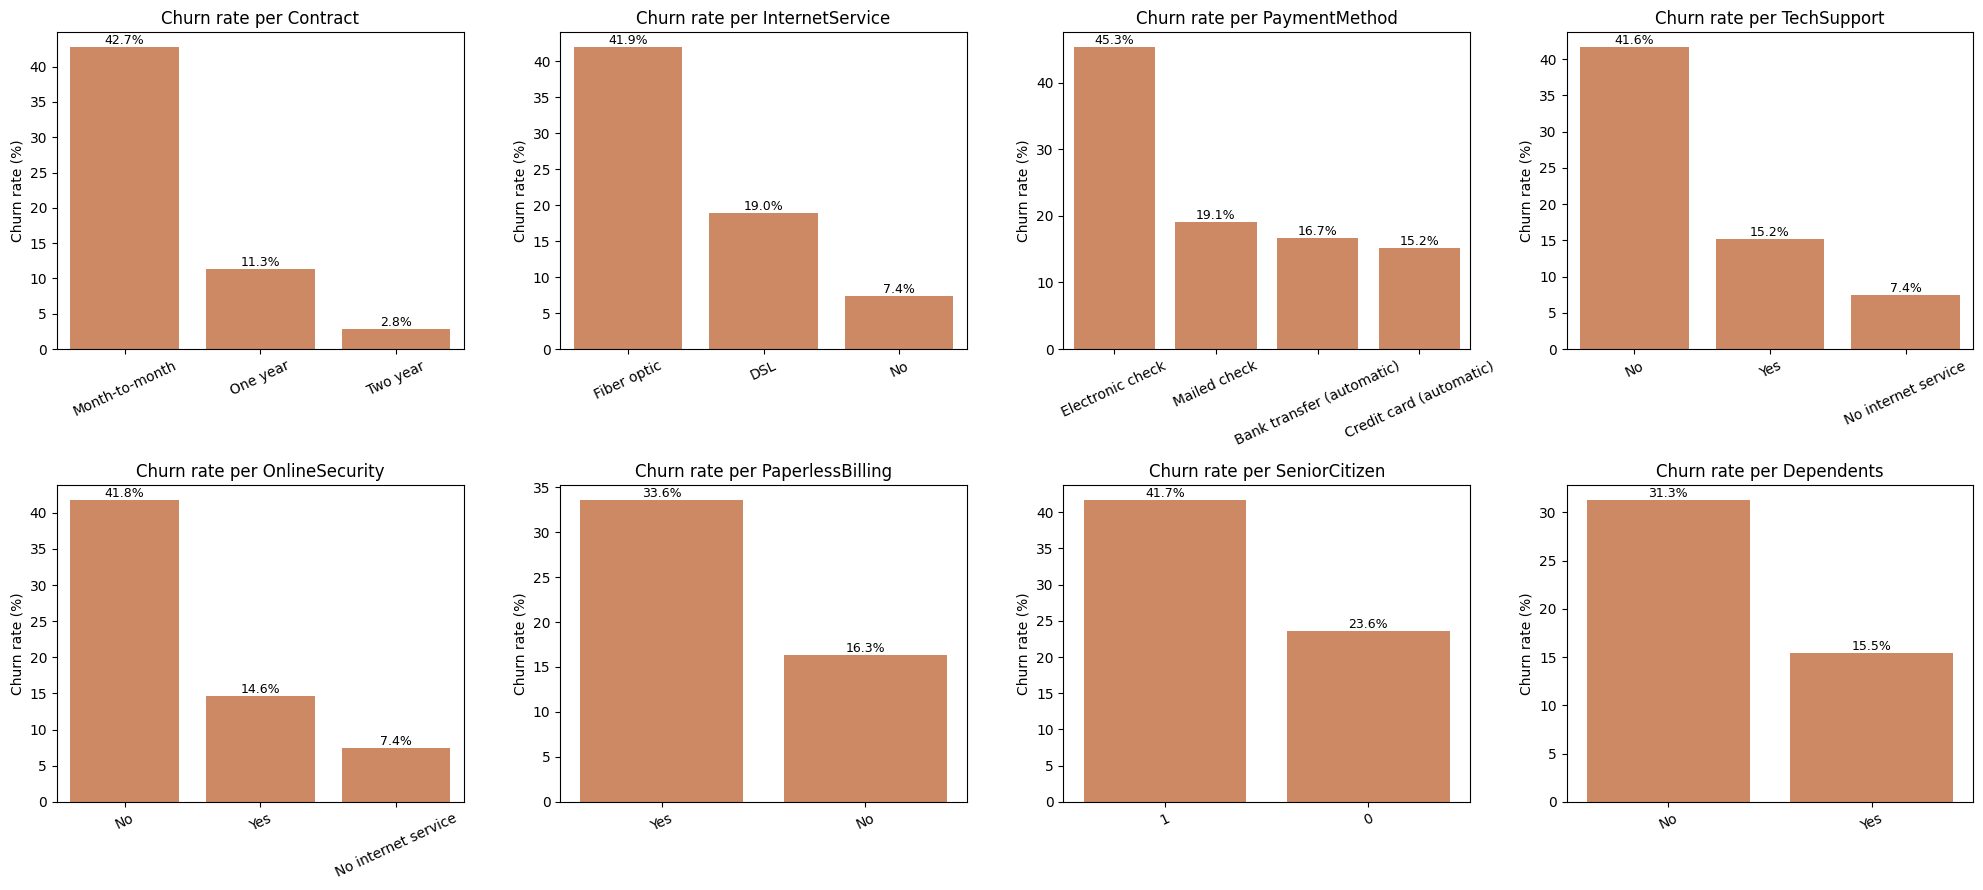

In [7]:
# Churn rate untuk fitur kategorikal yang paling relevan
cat_focus = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
             "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Dependents"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.ravel(), cat_focus):
    rate = (df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
              .sort_values(ascending=False))
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#DD8452")
    ax.set_title(f"Churn rate per {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
# Cek nilai kosong tersembunyi: TotalCharges berisi string spasi (" ") yang tidak terdeteksi isnull()
blank_tc = df["TotalCharges"].str.strip() == ""
print("Jumlah TotalCharges berupa string kosong:", blank_tc.sum())
print("Nilai tenure pada baris tersebut:", df.loc[blank_tc, "tenure"].unique())
print("Jumlah customerID duplikat:", df["customerID"].duplicated().sum())

Jumlah TotalCharges berupa string kosong: 11
Nilai tenure pada baris tersebut: [0]
Jumlah customerID duplikat: 0


- Dataset **imbalanced**: sekitar 73,5% pelanggan *No Churn* dan 26,5% *Churn*. Karena itu akurasi saja kurang cukup; Precision, Recall, dan F1-Score untuk kelas Churn juga perlu diperhatikan (baseline "selalu tebak No" sudah mendapat akurasi ±73,5%).
- Pelanggan yang churn cenderung memiliki **tenure pendek** dan **MonthlyCharges lebih tinggi**, sehingga TotalCharges mereka juga lebih rendah.
- Churn rate sangat tinggi pada kontrak **Month-to-month**, layanan internet **Fiber optic**, pembayaran **Electronic check**, serta pelanggan tanpa **TechSupport/OnlineSecurity**.
- Ada **missing value tersembunyi**: 11 baris `TotalCharges` berisi string kosong, semuanya pelanggan dengan `tenure = 0` (pelanggan baru yang belum ditagih). `df.isnull()` tidak mendeteksinya karena kolom masih bertipe object.

# 2. Preprocessing

In [10]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
data = df.copy()
data = data.drop(columns=["customerID"])  # ID unik, bukan fitur prediktif

# Ubah TotalCharges ke numerik; string kosong menjadi NaN
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
print("Missing value TotalCharges setelah konversi:", data["TotalCharges"].isna().sum())

# Strategi: semua baris NaN adalah pelanggan tenure = 0 yang belum pernah ditagih,
# sehingga TotalCharges yang logis adalah 0. Pengisian ini berbasis aturan per baris
# (tidak memakai statistik dari keseluruhan data seperti mean/median), jadi tidak ada data leakage.
data["TotalCharges"] = data["TotalCharges"].fillna(0)
print("Missing value setelah ditangani:", data.isna().sum().sum())

Missing value TotalCharges setelah konversi: 11
Missing value setelah ditangani: 0


In [11]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Target: Yes -> 1, No -> 0
data["Churn"] = (data["Churn"] == "Yes").astype(int)

# Fitur biner Yes/No dan gender -> 0/1
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    data[col] = (data[col] == "Yes").astype(int)
data["gender"] = (data["gender"] == "Male").astype(int)

# Fitur kategorikal multi-kelas -> One-Hot Encoding (nominal, tidak ada urutan)
multi_cat_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                  "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                  "Contract", "PaymentMethod"]
data = pd.get_dummies(data, columns=multi_cat_cols, drop_first=True, dtype=int)

print("Shape setelah encoding:", data.shape)
data.head()

Shape setelah encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [12]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Proporsi churn train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

X_train: (5634, 30) | X_test: (1409, 30)
Proporsi churn train: 0.265 | test: 0.265


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [13]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

# Fitur hasil encoding sudah bernilai 0/1 sehingga tidak perlu discaling
X_train_scaled[num_features].describe().round(3)

,tenure,MonthlyCharges,TotalCharges
count,5634.000,5634.000,5634.000
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-1.322,-1.544,-1.009
25%,-0.956,-0.971,-0.832
50%,-0.142,0.185,-0.397
75%,0.916,0.832,0.674
max,1.608,1.786,2.802


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [14]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).

baseline = MLPClassifier(hidden_layer_sizes=(10,), activation="relu",
                         max_iter=MAX_ITER, random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)
print("Jumlah iterasi:", baseline.n_iter_, "| konvergen:", baseline.n_iter_ < MAX_ITER)

Jumlah iterasi: 271 | konvergen: True


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_baseline = baseline.predict(X_test_scaled)

print("Akurasi train :", round(accuracy_score(y_train, baseline.predict(X_train_scaled)), 4))
print("Akurasi test  :", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Baseline 'selalu No' :", round(1 - y_test.mean(), 4))
print()
print(classification_report(y_test, y_pred_baseline, target_names=["No Churn", "Churn"]))

Akurasi train : 0.8159
Akurasi test  : 0.7906
Baseline 'selalu No' : 0.7346

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [16]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.

HIDDEN_ACT = (10,)
activations = ["relu", "tanh", "logistic"]
act_models = {}
for act in activations:
    m = MLPClassifier(hidden_layer_sizes=HIDDEN_ACT, activation=act,
                      max_iter=MAX_ITER, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    act_models[act] = m
    print(f"{act:9s} -> iterasi: {m.n_iter_}, konvergen: {m.n_iter_ < MAX_ITER}")

relu      -> iterasi: 271, konvergen: True
tanh      -> iterasi: 273, konvergen: True
logistic  -> iterasi: 161, konvergen: True


In [17]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

act_rows = []
for act, m in act_models.items():
    y_pred = m.predict(X_test_scaled)
    act_rows.append({
        "Activation": act,
        "Train Accuracy": accuracy_score(y_train, m.predict(X_train_scaled)),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "F1 (Churn)": f1_score(y_test, y_pred),
        "Iterasi": m.n_iter_,
    })
act_results = pd.DataFrame(act_rows).set_index("Activation")
display(act_results.round(4))

best_act = act_results["Test Accuracy"].idxmax()
tied = act_results.index[np.isclose(act_results["Test Accuracy"], act_results["Test Accuracy"].max())].tolist()
if len(tied) > 1:
    print("Catatan: test accuracy seri antara", tied, "-> idxmax mengambil yang pertama.")
print("Fungsi aktivasi terbaik (test accuracy):", best_act)

,Train Accuracy,Test Accuracy,F1 (Churn),Iterasi
Activation,,,,
relu,0.8159,0.7906,0.5551,271
tanh,0.8181,0.7977,0.5778,273
logistic,0.8064,0.7977,0.5827,161


Catatan: test accuracy seri antara ['tanh', 'logistic'] -> idxmax mengambil yang pertama.
Fungsi aktivasi terbaik (test accuracy): tanh


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [18]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.

architectures = [(2,), (5,), (10,), (50,), (100,), (100, 50), (200, 100), (256, 128, 64)]
arch_models = {}
for arch in architectures:
    m = MLPClassifier(hidden_layer_sizes=arch, activation=best_act,
                      max_iter=MAX_ITER, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    arch_models[str(arch)] = m
    print(f"{str(arch):15s} -> iterasi: {m.n_iter_}, konvergen: {m.n_iter_ < MAX_ITER}")

(2,)            -> iterasi: 136, konvergen: True
(5,)            -> iterasi: 107, konvergen: True
(10,)           -> iterasi: 273, konvergen: True
(50,)           -> iterasi: 300, konvergen: False
(100,)          -> iterasi: 300, konvergen: False
(100, 50)       -> iterasi: 300, konvergen: False
(200, 100)      -> iterasi: 300, konvergen: False
(256, 128, 64)  -> iterasi: 223, konvergen: True


In [19]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

arch_rows = []
for name, m in arch_models.items():
    y_pred = m.predict(X_test_scaled)
    train_acc = accuracy_score(y_train, m.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, y_pred)
    arch_rows.append({
        "Arsitektur": name,
        "Jumlah parameter": sum(w.size for w in m.coefs_) + sum(b.size for b in m.intercepts_),
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap (Train - Test)": train_acc - test_acc,
        "F1 (Churn)": f1_score(y_test, y_pred),
    })
arch_results = pd.DataFrame(arch_rows).set_index("Arsitektur")
display(arch_results.round(4))

best_arch = arch_results["Test Accuracy"].idxmax()
print("Arsitektur terbaik (test accuracy):", best_arch)

,Jumlah parameter,Train Accuracy,Test Accuracy,Gap (Train - Test),F1 (Churn)
Arsitektur,,,,,
"(2,)",65,0.8046,0.7956,0.0090,0.5897
"(5,)",161,0.8113,0.7984,0.0129,0.5884
"(10,)",321,0.8181,0.7977,0.0203,0.5778
"(50,)",1601,0.8308,0.7921,0.0388,0.5527
"(100,)",3201,0.8296,0.7821,0.0475,0.5397
"(100, 50)",8201,0.9274,0.7587,0.1687,0.5015
"(200, 100)",26401,0.9638,0.7544,0.2094,0.5057
"(256, 128, 64)",49153,0.9743,0.7516,0.2227,0.5084


Arsitektur terbaik (test accuracy): (5,)


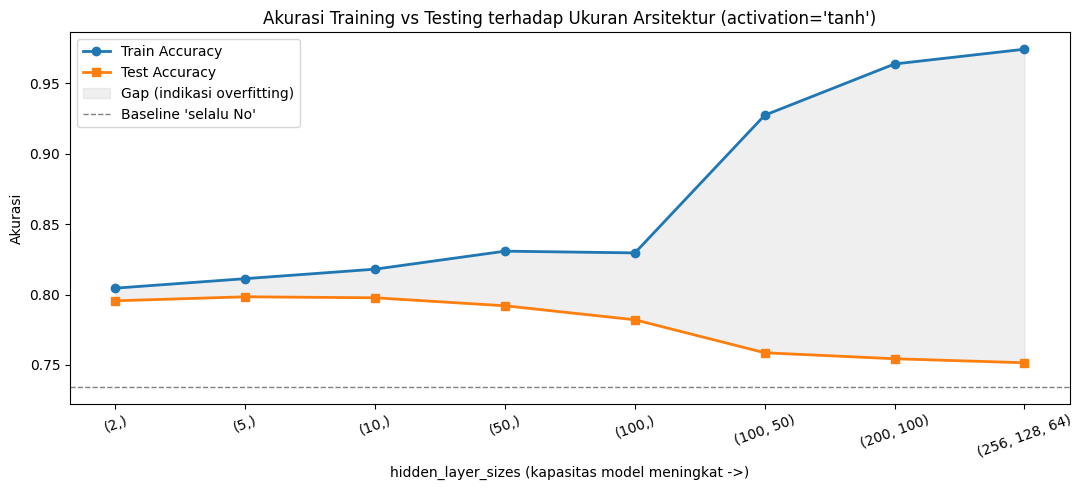

In [20]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(arch_results))
ax.plot(x, arch_results["Train Accuracy"], marker="o", lw=2, label="Train Accuracy")
ax.plot(x, arch_results["Test Accuracy"], marker="s", lw=2, label="Test Accuracy")
ax.fill_between(x, arch_results["Test Accuracy"], arch_results["Train Accuracy"],
                alpha=0.12, color="gray", label="Gap (indikasi overfitting)")
ax.axhline(1 - y_test.mean(), ls="--", color="gray", lw=1, label="Baseline 'selalu No'")
ax.set_xticks(x)
ax.set_xticklabels(arch_results.index, rotation=20)
ax.set_xlabel("hidden_layer_sizes (kapasitas model meningkat ->)")
ax.set_ylabel("Akurasi")
ax.set_title(f"Akurasi Training vs Testing terhadap Ukuran Arsitektur (activation='{best_act}')")
ax.legend()
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [22]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

def eval_row(label, m):
    y_pred = m.predict(X_test_scaled)
    return {"Model": label,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred)}

eval_table = pd.DataFrame([
    eval_row("Baseline relu (10,)", baseline),
    eval_row(f"Terbaik 3.2: {best_act} (10,)", act_models[best_act]),
    eval_row(f"Terbaik 3.3: {best_act} {best_arch}", arch_models[best_arch]),
    eval_row(f"Terbesar 3.3: {best_act} {architectures[-1]}", arch_models[str(architectures[-1])]),
]).set_index("Model")
display(eval_table.round(4))

best_model = arch_models[best_arch]
best_name = f"{best_act} {best_arch}"

,Accuracy,Precision,Recall,F1-Score
Model,,,,
"Baseline relu (10,)",0.7906,0.6367,0.4920,0.5551
"Terbaik 3.2: tanh (10,)",0.7977,0.6478,0.5214,0.5778
"Terbaik 3.3: tanh (5,)",0.7984,0.6424,0.5428,0.5884
"Terbesar 3.3: tanh (256, 128, 64)",0.7516,0.5355,0.4840,0.5084


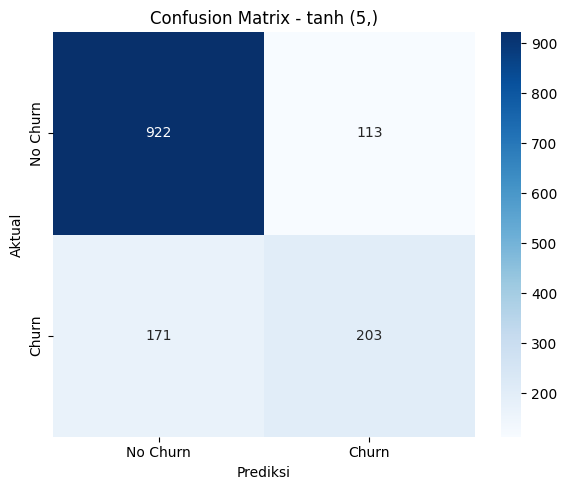

TN=922, FP=113, FN=171, TP=203


In [23]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Model terbaik berhenti di iterasi 107 dari max_iter=300 -> konvergen (early stop karena tol)
Loss akhir: 0.4076


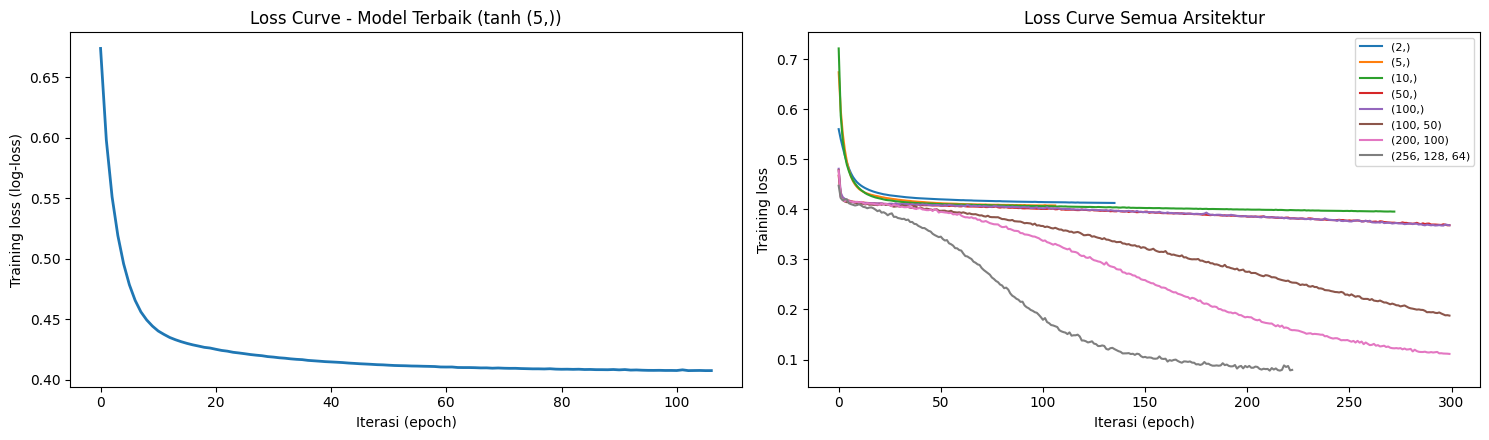

In [24]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].plot(best_model.loss_curve_, lw=2)
axes[0].set_title(f"Loss Curve - Model Terbaik ({best_name})")
axes[0].set_xlabel("Iterasi (epoch)")
axes[0].set_ylabel("Training loss (log-loss)")
print(f"Model terbaik berhenti di iterasi {best_model.n_iter_} dari max_iter={MAX_ITER}"
      f" -> {'konvergen (early stop karena tol)' if best_model.n_iter_ < MAX_ITER else 'BELUM konvergen'}")
print(f"Loss akhir: {best_model.loss_:.4f}")

# Pembanding: loss curve semua arsitektur
for name, m in arch_models.items():
    axes[1].plot(m.loss_curve_, label=name, lw=1.5)
axes[1].set_title("Loss Curve Semua Arsitektur")
axes[1].set_xlabel("Iterasi (epoch)")
axes[1].set_ylabel("Training loss")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**Jawab:**
### Hasil Analisis

**Konteks evaluasi.** Data test berisi 1.409 pelanggan dengan 26,5% churn. Model "selalu menebak No Churn" sudah mendapat akurasi 73,46%, jadi angka itulah batas bawah yang harus dilampaui. Semua model ANN di eksperimen ini berada di atasnya (75,2%–79,8%), tetapi karena data imbalanced, F1-Score kelas Churn lebih informatif daripada akurasi saja.

**1. Perbandingan fungsi aktivasi (arsitektur (10,), max_iter=300, random_state=42)**

| Activation | Train Acc | Test Acc | F1 (Churn) | Iterasi |
|---|---|---|---|---|
| ReLU | 0,8159 | 0,7906 | 0,5551 | 271 |
| Tanh | 0,8181 | 0,7977 | 0,5778 | 273 |
| Logistic | 0,8064 | 0,7977 | 0,5827 | 161 |

- Tanh dan Logistic **seri** pada akurasi test (0,7977), ReLU sedikit di bawah (0,7906). Selisih terbesarnya hanya 0,71 poin persen, atau sekitar **10 dari 1.409 sampel** test. Perbedaan ini **tidak signifikan**; dengan `random_state` atau split yang berbeda urutannya bisa saja berubah.
- Tanh dipilih untuk eksperimen 3.3 karena muncul pertama di antara yang seri. Logistic sebenarnya punya F1 sedikit lebih tinggi (0,583 vs 0,578), jadi keduanya sama-sama layak.
- **Kenapa hasilnya mirip?** (a) Pola pada data ini relatif sederhana dan sebagian besar hampir linear: churn sangat ditentukan oleh beberapa fitur kuat seperti `Contract`, `tenure`, `InternetService`, dan `PaymentMethod` (terlihat jelas di EDA). Untuk pola seperti ini, bentuk non-linearitas apa pun cukup. (b) Jaringan kecil (10 neuron, 1 hidden layer) tidak cukup dalam untuk mengalami masalah khas seperti *vanishing gradient* pada sigmoid/tanh atau *dying ReLU*. (c) Input sudah di-scaling, sehingga tanh/logistic bekerja di daerah gradien yang sehat dan tidak cepat jenuh.
- Satu perbedaan yang terlihat: **Logistic konvergen jauh lebih cepat** (161 iterasi vs ±270). ReLU memiliki akurasi train dan test sedikit lebih rendah daripada tanh, mengindikasikan boundary yang dipelajari sedikit lebih kasar, tetapi gap train-test ketiganya kecil (1–2,5 poin), artinya tidak ada yang overfit di ukuran ini.

**2. Eksperimen ukuran arsitektur (activation = tanh)**

| Arsitektur | Parameter | Train Acc | Test Acc | Gap | F1 (Churn) |
|---|---|---|---|---|---|
| (2,) | 65 | 0,8046 | 0,7956 | 0,009 | 0,590 |
| **(5,)** | 161 | 0,8113 | **0,7984** | 0,013 | 0,588 |
| (10,) | 321 | 0,8181 | 0,7977 | 0,020 | 0,578 |
| (50,) | 1.601 | 0,8308 | 0,7921 | 0,039 | 0,553 |
| (100,) | 3.201 | 0,8296 | 0,7821 | 0,048 | 0,540 |
| (100, 50) | 8.201 | 0,9274 | 0,7587 | 0,169 | 0,502 |
| (200, 100) | 26.401 | 0,9638 | 0,7544 | 0,209 | 0,506 |
| (256, 128, 64) | 49.153 | 0,9743 | 0,7516 | 0,223 | 0,508 |

- Akurasi test **mencapai puncak di (5,)** (0,7984) dan praktis datar sampai (10,). Model sekecil (2,) dengan hanya 65 parameter sudah hampir sama baiknya, menegaskan bahwa masalah ini tidak butuh kapasitas besar.
- **Gejala overfitting mulai muncul di (50,)**: akurasi train masih naik (0,818 → 0,831) sementara akurasi test mulai turun (0,798 → 0,792), dan gap membesar dua kali lipat (2,0 → 3,9 poin). Di (100,) tren ini berlanjut (test 0,782).
- **Overfitting menjadi parah ketika ditambah hidden layer kedua, (100, 50)**: akurasi train melonjak ke 92,7% sedangkan test justru jatuh ke 75,9%, gap 16,9 poin. Pada (256, 128, 64) model hampir menghafal data training (97,4%) tapi akurasi test (75,2%) hanya sedikit di atas baseline "selalu No".
- **Ciri di grafik:** kedua garis berdekatan pada arsitektur kecil, lalu mulai melebar (area abu-abu) sejak (50,). Garis train naik tajam, garis test turun perlahan, sehingga terbentuk pola "mulut buaya" yang menjadi tanda klasik overfitting. F1 kelas Churn juga turun dari ±0,59 ke ±0,50, artinya model besar paling dirugikan justru dalam mendeteksi pelanggan yang benar-benar churn.

**3. Konvergensi dan loss curve**

- Model terbaik **tanh (5,)** berhenti di iterasi **107 dari 300** dengan loss akhir **0,4076**. Kurvanya turun tajam di ±15 iterasi pertama lalu mendatar; scikit-learn menghentikan training karena perbaikan loss sudah di bawah `tol` selama 10 iterasi berturut-turut. Jadi model ini **sudah konvergen**.
- Pada grafik pembanding, arsitektur (50,), (100,), (100, 50), dan (200, 100) **mencapai max_iter=300 sebelum konvergen**. Untuk (100, 50) dan (200, 100) loss masih turun cukup tajam (±0,19 dan ±0,11) saat dihentikan. Perlu dicatat: loss training yang terus turun ini **bukan kabar baik**, karena di saat yang sama akurasi test memburuk. Turunnya loss di sini adalah proses model menghafal data training.
- **Jika loss masih turun tajam saat max_iter tercapai**, langkah yang saya ambil: (1) naikkan `max_iter` agar model benar-benar konvergen; (2) **tetapi** pantau performa di data validasi, misalnya dengan `early_stopping=True` (`validation_fraction=0.1`, `n_iter_no_change`), sehingga training berhenti saat skor validasi berhenti membaik, bukan saat loss train berhenti turun; (3) bila model besar tetap overfit, tambahkan regularisasi L2 lewat `alpha` atau kecilkan arsitekturnya; (4) cek `learning_rate_init` bila penurunan loss terlalu lambat.

**4. Evaluasi model terbaik (tanh (5,))**

- Accuracy 0,7984 | Precision 0,6424 | Recall 0,5428 | F1 0,5884 (kelas Churn).
- Confusion matrix: TN=922, FP=113, **FN=171**, TP=203. Model menangkap 203 dari 374 pelanggan churn (54%) dan melewatkan 171. Untuk kasus bisnis churn, FN biasanya lebih mahal (pelanggan pergi tanpa sempat dicegah) daripada FP (diberi promo retensi padahal tidak akan pergi), sehingga **recall masih menjadi titik lemah** utama model.
- Dibanding baseline relu (10,), model terbaik naik di semua metrik, dengan kenaikan terbesar di Recall (0,492 → 0,543). Model terbesar (256, 128, 64) paling buruk di semua metrik, terutama Precision (0,536).

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Jawab:**
### Kesimpulan

1. ANN (MLPClassifier) berhasil memprediksi churn pelanggan Telco dengan akurasi terbaik 79,84% dan F1 kelas Churn 0,588, menggunakan arsitektur sederhana satu hidden layer berisi 5 neuron dengan aktivasi tanh. Ini sekitar 6,4 poin di atas baseline "selalu tebak No Churn" (73,46%).
2. Pilihan fungsi aktivasi tidak berpengaruh signifikan** pada dataset ini: tanh dan logistic seri (79,77%), ReLU 79,06%. Selisihnya hanya ±10 sampel test. Perbedaan yang paling terasa justru kecepatan konvergensi (logistic paling cepat).
3. Ukuran arsitektur sangat berpengaruh. Kapasitas kecil (2–10 neuron) sudah optimal. Gejala overfitting mulai terlihat di (50,) dan menjadi parah sejak penambahan hidden layer kedua (100, 50), di mana akurasi train >92% tetapi akurasi test turun ke <76%. Untuk data tabular berukuran sedang dengan pola sederhana seperti ini, model yang lebih besar bukan berarti lebih baik.
4. Model terbaik sudah konvergen (berhenti di iterasi 107/300). Model besar yang belum konvergen di iterasi 300 justru menunjukkan bahwa menurunkan loss train secara terus-menerus akan memperparah overfitting.
5. Kelemahan utama model adalah recall kelas Churn yang baru 54%, akibat data yang imbalanced.

### Saran

- Validasi yang lebih ketat dengan pemilihan aktivasi dan arsitektur di tugas ini mengikuti instruksi (berdasarkan akurasi test). Idealnya model dipilih memakai validation set atau cross_val_score/StratifiedKFold, lalu test set hanya dipakai sekali di akhir, agar estimasi performa tidak bias optimis. Mengulang eksperimen dengan beberapa random_state juga akan menunjukkan apakah selisih antar aktivasi memang hanya noise.
- Hyperparameter tuning dengan GridSearchCV pada hidden_layer_sizes, activation, alpha (regularisasi L2, misalnya 1e-4 s.d. 1), learning_rate_init, dan batch_size, dengan scoring="f1" atau "recall" karena fokus bisnisnya adalah menangkap pelanggan churn.
- Aktifkan early_stopping=True agar arsitektur besar berhenti otomatis sebelum mulai menghafal data, lalu bandingkan ulang hasilnya dengan eksperimen 3.3.
- Mencoba solver lain seperti 'sgd' dengan momentum/learning rate adaptif, atau 'lbfgs' yang sering lebih cepat dan stabil untuk dataset kecil.
- Menangani imbalance: menurunkan decision threshold (misalnya dari 0,5 ke 0,3–0,4 berdasarkan predict_proba dan kurva precision-recall), atau oversampling kelas Churn (SMOTE / RandomOverSampler di dalam pipeline train saja).
- Membandingkan dengan model lain seperti Logistic Regression, Random Forest, dan Gradient Boosting (XGBoost/LightGBM). Untuk data tabular seperti ini, model tersebut sering setara atau lebih baik daripada ANN, sekaligus lebih mudah diinterpretasi.
- Feature engineering, misalnya rata-rata tagihan per bulan (TotalCharges / tenure), jumlah layanan tambahan yang diambil, atau kelompok tenure, yang secara bisnis berkaitan erat dengan churn.